In [13]:
# =============================================================================
# CELL 1: Import Libraries
# =============================================================================
# We import only what we need, with clear purposes for each library

# %pip install numpy pandas matplotlib opencv-python pillow tensorflow

import os                          # File and directory operations
import numpy as np                 # Numerical operations
import pandas as pd                # Data manipulation
import matplotlib.pyplot as plt    # Visualization
import cv2                         # Image processing (OpenCV)
from PIL import Image              # Image loading for display
from collections import Counter    # Count occurrences

# We'll import TensorFlow/sklearn later when needed
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


# Data Preprocessing Notebook

## Objective
Prepare the handwriting dataset for training a CNN model that identifies writers based on their handwriting.

## Key Steps
1. **Verify** dataset is in place
2. **Understand** the data structure and naming convention
3. **Extract** labels from filenames
4. **Analyze** image properties
5. **Preprocess** images (resize, grayscale, normalize)
6. **Save** preprocessed data for training

---
## Step 1: Setup & Path Configuration

In [14]:
# =============================================================================
# CELL 2: Define Paths
# =============================================================================
# Set up all paths relative to the notebook location

# Get the base directory (parent of 'notebooks' folder)
BASE_DIR = os.path.dirname(os.getcwd())

# Define data directories
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')

# Output directory for preprocessed data
PREPROCESSED_DIR = os.path.join(BASE_DIR, 'preprocessed')

# Print paths for verification
print("PATH CONFIGURATION")
print("=" * 60)
print(f"Base directory:     {BASE_DIR}")
print(f"Train directory:    {TRAIN_DIR}")
print(f"Test directory:     {TEST_DIR}")
print(f"Preprocessed dir:   {PREPROCESSED_DIR}")

PATH CONFIGURATION
Base directory:     c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition
Train directory:    c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\train
Test directory:     c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\test
Preprocessed dir:   c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\preprocessed


In [15]:
# =============================================================================
# CELL 3: Verify Dataset Exists
# =============================================================================
# Check that the data folders exist and contain images

def verify_directory(dir_path, dir_name):
    """Check if directory exists and count image files"""
    if not os.path.exists(dir_path):
        print(f"❌ {dir_name} directory NOT FOUND: {dir_path}")
        return False, 0
    
    # Count image files (png, jpg, jpeg)
    image_files = [f for f in os.listdir(dir_path) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if len(image_files) == 0:
        print(f"⚠️  {dir_name} directory exists but is EMPTY")
        return True, 0
    
    print(f"✓ {dir_name} directory: {len(image_files)} images found")
    return True, len(image_files)

print("DATASET VERIFICATION")
print("=" * 60)
train_exists, train_count = verify_directory(TRAIN_DIR, "Train")
test_exists, test_count = verify_directory(TEST_DIR, "Test")

# Summary
print("\n" + "-" * 60)
if train_count > 0 and test_count > 0:
    print("✓ Dataset is ready for preprocessing!")
else:
    print("❌ Please copy images to the train/ and test/ folders first.")

DATASET VERIFICATION
✓ Train directory: 70 images found
✓ Test directory: 140 images found

------------------------------------------------------------
✓ Dataset is ready for preprocessing!


---
## Step 2: Understand the Data Structure

According to the project specification:
- Images are stored in a **flat structure** (no subfolders)
- Writer ID is encoded in the **first 2 characters** of the filename
- Example: `01_9_999.png` → Writer ID = `01`

Let's examine the actual files to confirm this.

In [16]:
# =============================================================================
# CELL 4: Examine Sample Filenames
# =============================================================================
# Look at actual filenames to understand the naming pattern

def examine_filenames(dir_path, num_samples=10):
    """Display sample filenames and analyze their structure"""
    image_files = sorted([f for f in os.listdir(dir_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"Total files: {len(image_files)}")
    print(f"\nFirst {num_samples} filenames:")
    print("-" * 40)
    
    for i, filename in enumerate(image_files[:num_samples]):
        # Split filename to understand structure
        parts = filename.split('_')
        print(f"  {filename}")
        print(f"    → Parts: {parts}")
        print(f"    → First 2 chars: '{filename[:2]}'")
    
    return image_files

print("TRAINING DATA - FILENAME ANALYSIS")
print("=" * 60)
train_files = examine_filenames(TRAIN_DIR)

TRAINING DATA - FILENAME ANALYSIS
Total files: 70

First 10 filenames:
----------------------------------------
  01_1_631.png
    → Parts: ['01', '1', '631.png']
    → First 2 chars: '01'
  02_1_632.png
    → Parts: ['02', '1', '632.png']
    → First 2 chars: '02'
  03_1_633.png
    → Parts: ['03', '1', '633.png']
    → First 2 chars: '03'
  04_1_634.png
    → Parts: ['04', '1', '634.png']
    → First 2 chars: '04'
  05_1_635.png
    → Parts: ['05', '1', '635.png']
    → First 2 chars: '05'
  06_1_636.png
    → Parts: ['06', '1', '636.png']
    → First 2 chars: '06'
  07_1_637.png
    → Parts: ['07', '1', '637.png']
    → First 2 chars: '07'
  08_1_638.png
    → Parts: ['08', '1', '638.png']
    → First 2 chars: '08'
  09_1_639.png
    → Parts: ['09', '1', '639.png']
    → First 2 chars: '09'
  10_1_640.png
    → Parts: ['10', '1', '640.png']
    → First 2 chars: '10'


In [17]:
# =============================================================================
# CELL 5: Verify Label Extraction Logic
# =============================================================================
# Test our label extraction function on real filenames

def extract_label(filename):
    """
    Extract writer ID from filename.
    
    Rule: First 2 characters of filename = Writer ID
    Example: '01_9_999.png' → '01'
    
    Returns: string (e.g., '01', '02', ..., '70')
    """
    return filename[:2]

# Test on sample filenames
print("LABEL EXTRACTION TEST")
print("=" * 60)

test_filenames = ['01_1_631.png', '25_1_655.png', '70_1_700.png', '05_2_495.png']
print("Testing extract_label() function:\n")

for fname in test_filenames:
    label = extract_label(fname)
    print(f"  '{fname}' → Writer ID: '{label}'")

# Apply to all training files
print("\n" + "-" * 60)
all_train_labels = [extract_label(f) for f in train_files]
unique_labels = sorted(set(all_train_labels))

print(f"Total training files: {len(all_train_labels)}")
print(f"Unique writers found: {len(unique_labels)}")
print(f"Writer IDs: {unique_labels}")

LABEL EXTRACTION TEST
Testing extract_label() function:

  '01_1_631.png' → Writer ID: '01'
  '25_1_655.png' → Writer ID: '25'
  '70_1_700.png' → Writer ID: '70'
  '05_2_495.png' → Writer ID: '05'

------------------------------------------------------------
Total training files: 70
Unique writers found: 70
Writer IDs: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70']


In [18]:
# =============================================================================
# CELL 6: Analyze Class Distribution
# =============================================================================
# Count how many samples per writer (class balance check)

def analyze_class_distribution(labels, dataset_name="Dataset"):
    """Analyze and visualize the distribution of classes"""
    label_counts = Counter(labels)
    
    print(f"{dataset_name.upper()} - CLASS DISTRIBUTION")
    print("=" * 60)
    print(f"Total samples: {len(labels)}")
    print(f"Number of classes (writers): {len(label_counts)}")
    print(f"Samples per class:")
    
    # Sort by label
    for label in sorted(label_counts.keys()):
        count = label_counts[label]
        bar = '█' * count
        print(f"  Writer {label}: {count} sample(s) {bar}")
    
    # Statistics
    counts = list(label_counts.values())
    print(f"\nStatistics:")
    print(f"  Min samples per class: {min(counts)}")
    print(f"  Max samples per class: {max(counts)}")
    print(f"  Mean samples per class: {np.mean(counts):.2f}")
    
    return label_counts

train_label_counts = analyze_class_distribution(all_train_labels, "Training")

TRAINING - CLASS DISTRIBUTION
Total samples: 70
Number of classes (writers): 70
Samples per class:
  Writer 01: 1 sample(s) █
  Writer 02: 1 sample(s) █
  Writer 03: 1 sample(s) █
  Writer 04: 1 sample(s) █
  Writer 05: 1 sample(s) █
  Writer 06: 1 sample(s) █
  Writer 07: 1 sample(s) █
  Writer 08: 1 sample(s) █
  Writer 09: 1 sample(s) █
  Writer 10: 1 sample(s) █
  Writer 11: 1 sample(s) █
  Writer 12: 1 sample(s) █
  Writer 13: 1 sample(s) █
  Writer 14: 1 sample(s) █
  Writer 15: 1 sample(s) █
  Writer 16: 1 sample(s) █
  Writer 17: 1 sample(s) █
  Writer 18: 1 sample(s) █
  Writer 19: 1 sample(s) █
  Writer 20: 1 sample(s) █
  Writer 21: 1 sample(s) █
  Writer 22: 1 sample(s) █
  Writer 23: 1 sample(s) █
  Writer 24: 1 sample(s) █
  Writer 25: 1 sample(s) █
  Writer 26: 1 sample(s) █
  Writer 27: 1 sample(s) █
  Writer 28: 1 sample(s) █
  Writer 29: 1 sample(s) █
  Writer 30: 1 sample(s) █
  Writer 31: 1 sample(s) █
  Writer 32: 1 sample(s) █
  Writer 33: 1 sample(s) █
  Writer 3

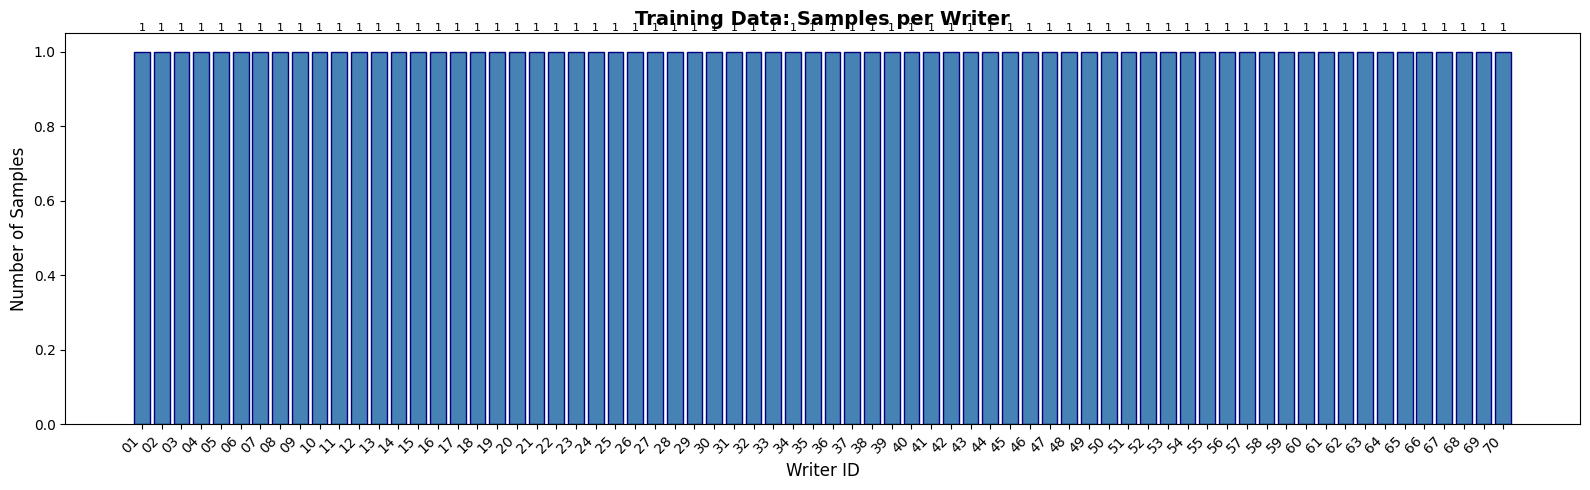


⚠️  Note: With only 1 sample(s) per writer, 
   data augmentation will be CRITICAL for training.


In [19]:
# =============================================================================
# CELL 7: Visualize Class Distribution
# =============================================================================
# Create a bar chart of samples per writer

plt.figure(figsize=(16, 5))

labels = sorted(train_label_counts.keys())
counts = [train_label_counts[l] for l in labels]

plt.bar(labels, counts, color='steelblue', edgecolor='navy')
plt.xlabel('Writer ID', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Training Data: Samples per Writer', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for i, (label, count) in enumerate(zip(labels, counts)):
    plt.text(i, count + 0.05, str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n⚠️  Note: With only {np.mean(counts):.0f} sample(s) per writer, ")
print("   data augmentation will be CRITICAL for training.")

---
## Step 3: Analyze Image Properties

Before preprocessing, we need to understand:
- Image dimensions (width × height)
- Color mode (grayscale or RGB)
- File sizes
- Pixel value ranges

In [20]:
# =============================================================================
# CELL 8: Analyze Image Properties
# =============================================================================
# Examine the properties of actual images

def analyze_single_image(image_path):
    """Get properties of a single image"""
    # Load with OpenCV
    img_cv = cv2.imread(image_path)
    
    # Load with PIL for comparison
    img_pil = Image.open(image_path)
    
    return {
        'filename': os.path.basename(image_path),
        'cv2_shape': img_cv.shape if img_cv is not None else None,
        'pil_size': img_pil.size,  # (width, height)
        'pil_mode': img_pil.mode,
        'file_size_kb': os.path.getsize(image_path) / 1024
    }

def analyze_dataset_images(dir_path, sample_size=None):
    """Analyze properties of images in a directory"""
    image_files = sorted([f for f in os.listdir(dir_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    if sample_size:
        image_files = image_files[:sample_size]
    
    properties = []
    for filename in image_files:
        filepath = os.path.join(dir_path, filename)
        props = analyze_single_image(filepath)
        properties.append(props)
    
    return pd.DataFrame(properties)

# Analyze all training images
print("IMAGE PROPERTIES ANALYSIS")
print("=" * 60)

props_df = analyze_dataset_images(TRAIN_DIR)

print(f"Analyzed {len(props_df)} images\n")
print("Sample of image properties:")
print(props_df.head(10).to_string(index=False))

IMAGE PROPERTIES ANALYSIS
Analyzed 70 images

Sample of image properties:
    filename       cv2_shape     pil_size pil_mode  file_size_kb
01_1_631.png (1070, 1545, 3) (1545, 1070)        P    204.186523
02_1_632.png (1070, 1545, 3) (1545, 1070)        P    204.186523
03_1_633.png (1070, 1545, 3) (1545, 1070)        P    204.186523
04_1_634.png (1070, 1545, 3) (1545, 1070)        P    204.186523
05_1_635.png (1070, 1545, 3) (1545, 1070)        P    204.186523
06_1_636.png (1070, 1545, 3) (1545, 1070)        P    204.186523
07_1_637.png (1070, 1545, 3) (1545, 1070)        P    204.186523
08_1_638.png (1070, 1545, 3) (1545, 1070)        P    204.186523
09_1_639.png (1070, 1545, 3) (1545, 1070)        P    204.186523
10_1_640.png (1070, 1545, 3) (1545, 1070)        P    204.186523


In [21]:
# =============================================================================
# CELL 9: Summarize Image Properties
# =============================================================================
# Extract and display summary statistics

# Extract dimensions from cv2_shape (height, width, channels)
props_df['height'] = props_df['cv2_shape'].apply(lambda x: x[0] if x is not None else None)
props_df['width'] = props_df['cv2_shape'].apply(lambda x: x[1] if x is not None else None)
props_df['channels'] = props_df['cv2_shape'].apply(lambda x: x[2] if x is not None and len(x) > 2 else 1)

print("IMAGE DIMENSIONS SUMMARY")
print("=" * 60)
print(f"Height  - Min: {props_df['height'].min()}, Max: {props_df['height'].max()}, Mean: {props_df['height'].mean():.0f}")
print(f"Width   - Min: {props_df['width'].min()}, Max: {props_df['width'].max()}, Mean: {props_df['width'].mean():.0f}")
print(f"Channels: {props_df['channels'].unique()} (1=Grayscale, 3=RGB)")
print(f"Color mode (PIL): {props_df['pil_mode'].unique()}")
print(f"\nFile sizes:")
print(f"  Min: {props_df['file_size_kb'].min():.1f} KB")
print(f"  Max: {props_df['file_size_kb'].max():.1f} KB")
print(f"  Mean: {props_df['file_size_kb'].mean():.1f} KB")

# Check if all images have same dimensions
unique_dims = props_df[['height', 'width']].drop_duplicates()
if len(unique_dims) == 1:
    print(f"\n✓ All images have the same dimensions: {unique_dims.iloc[0]['width']}×{unique_dims.iloc[0]['height']}")
else:
    print(f"\n⚠️  Images have varying dimensions:")
    print(unique_dims.to_string(index=False))

IMAGE DIMENSIONS SUMMARY
Height  - Min: 1070, Max: 1070, Mean: 1070
Width   - Min: 1545, Max: 1545, Mean: 1545
Channels: [3] (1=Grayscale, 3=RGB)
Color mode (PIL): ['P']

File sizes:
  Min: 204.2 KB
  Max: 204.2 KB
  Mean: 204.2 KB

✓ All images have the same dimensions: 1545×1070


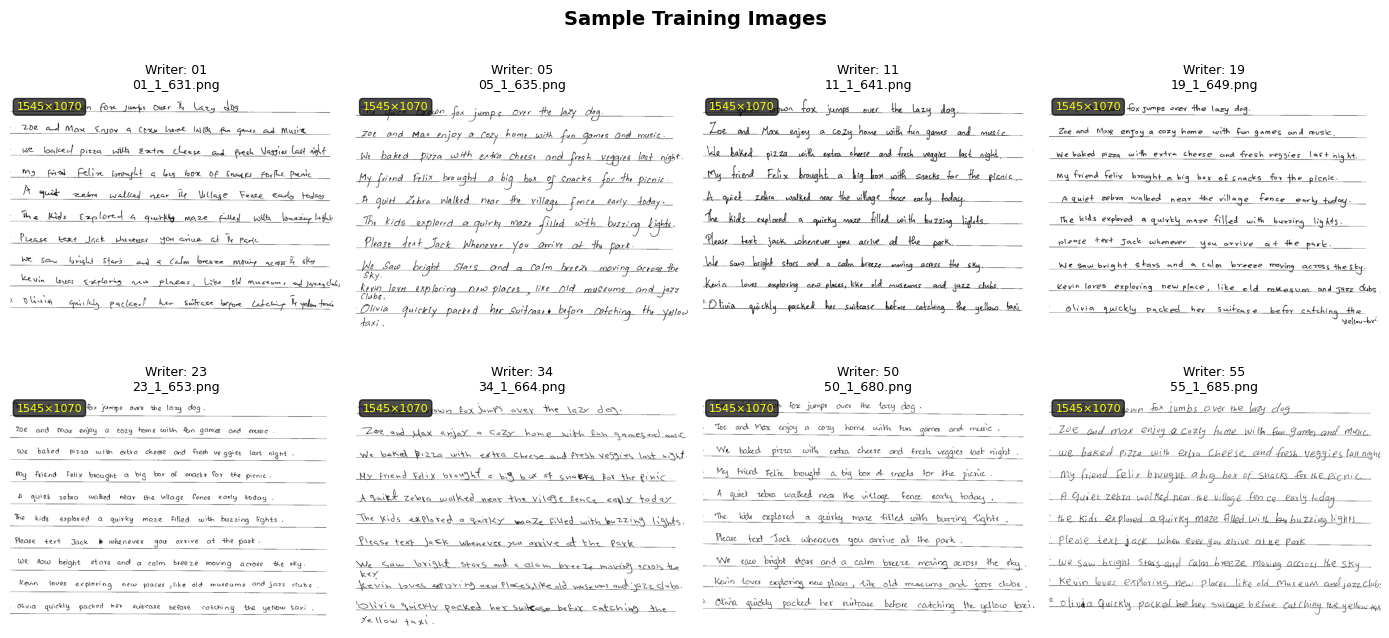

In [22]:
# =============================================================================
# CELL 10: Display Sample Images
# =============================================================================
# Visualize a few sample images from different writers

def display_sample_images(dir_path, num_samples=8, seed=42, title="Sample Images"):
    """Display random sample images from the dataset"""
    np.random.seed(seed)
    
    image_files = sorted([f for f in os.listdir(dir_path) 
                          if f.lower().endswith('.png')])
    
    # Select random samples
    sample_indices = np.random.choice(len(image_files), 
                                       min(num_samples, len(image_files)), 
                                       replace=False)
    sample_files = [image_files[i] for i in sorted(sample_indices)]
    
    # Create grid
    cols = 4
    rows = (len(sample_files) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.flatten()
    
    for i, filename in enumerate(sample_files):
        filepath = os.path.join(dir_path, filename)
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        
        writer_id = extract_label(filename)
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Writer: {writer_id}\n{filename}", fontsize=9)
        axes[i].axis('off')
        
        # Add image dimensions
        axes[i].text(0.02, 0.98, f"{img.shape[1]}×{img.shape[0]}", 
                     transform=axes[i].transAxes, fontsize=8,
                     verticalalignment='top', color='yellow',
                     bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    
    # Hide empty subplots
    for i in range(len(sample_files), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

display_sample_images(TRAIN_DIR, num_samples=8, title="Sample Training Images")

SAMPLE TEST IMAGES


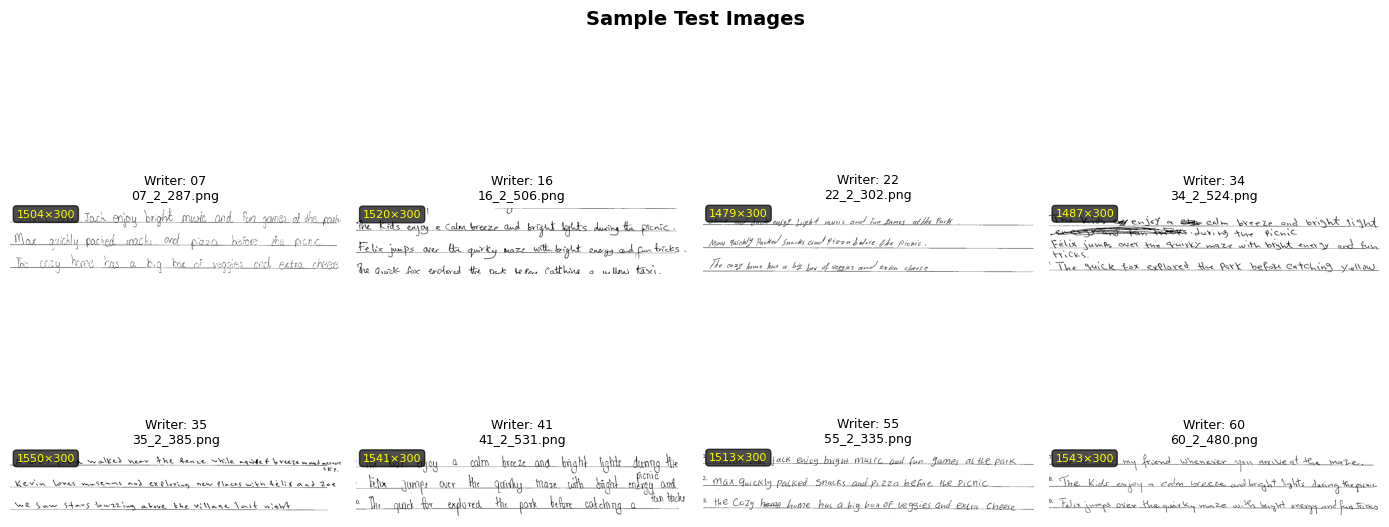



TEST - CLASS DISTRIBUTION
Total samples: 140
Number of classes (writers): 70
Samples per class:
  Writer 01: 2 sample(s) ██
  Writer 02: 2 sample(s) ██
  Writer 03: 2 sample(s) ██
  Writer 04: 2 sample(s) ██
  Writer 05: 2 sample(s) ██
  Writer 06: 2 sample(s) ██
  Writer 07: 2 sample(s) ██
  Writer 08: 2 sample(s) ██
  Writer 09: 2 sample(s) ██
  Writer 10: 2 sample(s) ██
  Writer 11: 2 sample(s) ██
  Writer 12: 2 sample(s) ██
  Writer 13: 2 sample(s) ██
  Writer 14: 2 sample(s) ██
  Writer 15: 2 sample(s) ██
  Writer 16: 2 sample(s) ██
  Writer 17: 2 sample(s) ██
  Writer 18: 2 sample(s) ██
  Writer 19: 2 sample(s) ██
  Writer 20: 2 sample(s) ██
  Writer 21: 2 sample(s) ██
  Writer 22: 2 sample(s) ██
  Writer 23: 2 sample(s) ██
  Writer 24: 2 sample(s) ██
  Writer 25: 2 sample(s) ██
  Writer 26: 2 sample(s) ██
  Writer 27: 2 sample(s) ██
  Writer 28: 2 sample(s) ██
  Writer 29: 2 sample(s) ██
  Writer 30: 2 sample(s) ██
  Writer 31: 2 sample(s) ██
  Writer 32: 2 sample(s) ██
  Writ

In [23]:
# =============================================================================
# CELL 10b: Display Sample Test Images
# =============================================================================
# Visualize a few sample images from the test set

print("SAMPLE TEST IMAGES")
print("=" * 60)
display_sample_images(TEST_DIR, num_samples=8, title="Sample Test Images")

# Also show class distribution for test data
print("\n")
test_files = sorted([f for f in os.listdir(TEST_DIR) 
                     if f.lower().endswith('.png')])
all_test_labels = [extract_label(f) for f in test_files]
test_label_counts = analyze_class_distribution(all_test_labels, "Test")

---
## Step 4: Define Preprocessing Pipeline

Based on our analysis, we'll apply these NEW preprocessing steps:

In [24]:
# =============================================================================
# IMPROVED Patch-based preprocessing configuration
# =============================================================================

# IMPROVED: Larger square patches capture more contextual information
# 128×128 patches contain more strokes and connections than 128×64
PATCH_H = 128
PATCH_W = 128  # INCREASED from 64 to 128 for more context

# IMPROVED: 50% overlap in both directions
# Generates more diverse training patches
STRIDE_Y = 64
STRIDE_X = 64  # Adjusted for square patches

# Adaptive threshold parameters (must be odd block size)
ADAPTIVE_BLOCK_SIZE = 31
ADAPTIVE_C = 10

# Filter out mostly-empty patches (ink is 1.0 after inversion)
# Slightly higher threshold to ensure meaningful patches
MIN_INK_RATIO = 0.02  # Increased from 0.01

# IMPROVED: More patches per image since we have more overlapping coverage
MAX_PATCHES_PER_IMAGE = 200  # Increased from 150

# Random seed (for reproducible patch sampling)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("IMPROVED PATCH CONFIGURATION")
print("=" * 60)
print(f"Patch size: {PATCH_H}×{PATCH_W} (SQUARE - more context)")
print(f"Stride:    y={STRIDE_Y}, x={STRIDE_X} (50% overlap)")
print(f"Adaptive threshold: block={ADAPTIVE_BLOCK_SIZE}, C={ADAPTIVE_C}")
print(f"Min ink ratio: {MIN_INK_RATIO}")
print(f"Max patches per image: {MAX_PATCHES_PER_IMAGE}")
print("\nKey improvements:")
print("  - Square 128×128 patches capture more writing patterns")
print("  - 50% overlap generates diverse training samples")
print("  - More patches per image for better coverage")

IMPROVED PATCH CONFIGURATION
Patch size: 128×128 (SQUARE - more context)
Stride:    y=64, x=64 (50% overlap)
Adaptive threshold: block=31, C=10
Min ink ratio: 0.02
Max patches per image: 200

Key improvements:
  - Square 128×128 patches capture more writing patterns
  - 50% overlap generates diverse training samples
  - More patches per image for better coverage


In [25]:
# =============================================================================
# Preprocess full image (style-preserving)
# =============================================================================

def preprocess_full_image(image_path, verbose=False):
    """
    Returns a normalized image in range [0,1] where:
      background ≈ 0
      ink ≈ 1
    Shape: (H, W)
    """
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Failed to load image: {image_path}")

    # Conservative denoising
    gray = cv2.medianBlur(gray, 3)

    # Adaptive threshold (light touch)
    thr = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        ADAPTIVE_BLOCK_SIZE,
        ADAPTIVE_C,
    )

    # Invert so ink becomes white (255), background black (0)
    inv = 255 - thr

    # Normalize to [0,1]
    img = inv.astype(np.float32) / 255.0

    if verbose:
        print(f"Loaded: {gray.shape}, after threshold: range [{img.min():.3f}, {img.max():.3f}]")

    return img

In [26]:
# =============================================================================
# Patch extraction
# =============================================================================

def extract_patches(img, patch_h=PATCH_H, patch_w=PATCH_W, stride_y=STRIDE_Y, stride_x=STRIDE_X,
                    min_ink_ratio=MIN_INK_RATIO, max_patches=MAX_PATCHES_PER_IMAGE):
    """
    img: (H, W) float32 in [0,1], ink ~ 1
    Returns:
      patches: (N, patch_h, patch_w, 1)
      coords:  list of (y, x) top-left coords
    """
    H, W = img.shape
    patches = []
    coords = []

    # If image is smaller than patch size, skip (or you could pad, but simplest is skip)
    if H < patch_h or W < patch_w:
        return np.zeros((0, patch_h, patch_w, 1), dtype=np.float32), []

    for y in range(0, H - patch_h + 1, stride_y):
        for x in range(0, W - patch_w + 1, stride_x):
            patch = img[y:y + patch_h, x:x + patch_w]
            if patch.mean() < min_ink_ratio:
                continue
            patches.append(patch[..., None])  # add channel dim
            coords.append((y, x))

    if len(patches) == 0:
        return np.zeros((0, patch_h, patch_w, 1), dtype=np.float32), []

    # Cap patches per image (randomly sample) to control dataset size/balance
    if max_patches is not None and len(patches) > max_patches:
        idx = rng.choice(len(patches), size=max_patches, replace=False)
        patches = [patches[i] for i in idx]
        coords = [coords[i] for i in idx]

    return np.stack(patches, axis=0).astype(np.float32), coords

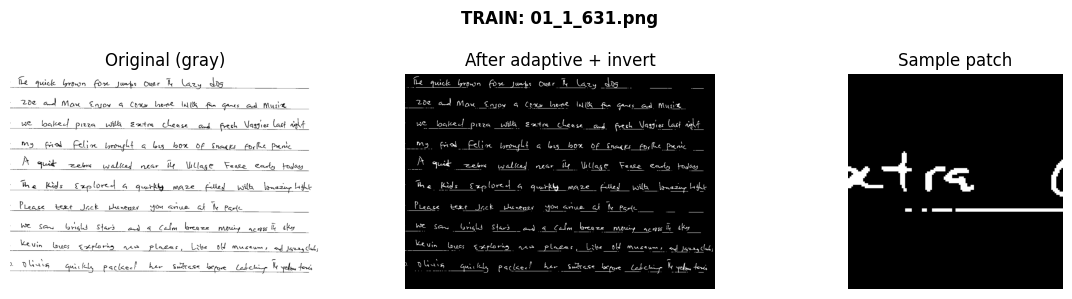

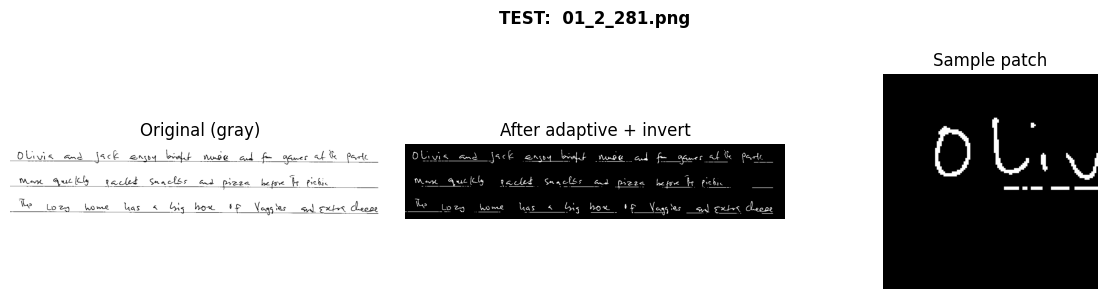

In [27]:
# =============================================================================
# Quick visual sanity check: train and test preprocessing
# =============================================================================

def show_preprocess_preview(image_path, title="Preview"):
    img = preprocess_full_image(image_path)
    patches, _ = extract_patches(img)

    plt.figure(figsize=(12, 3))
    plt.subplot(1, 3, 1)
    raw = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    plt.imshow(raw, cmap="gray")
    plt.title("Original (gray)")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(img, cmap="gray")
    plt.title("After adaptive + invert")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    if len(patches) > 0:
        plt.imshow(patches[0].squeeze(), cmap="gray")
        plt.title("Sample patch")
    else:
        plt.title("No patches extracted")
    plt.axis("off")

    plt.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

train_sample = sorted([f for f in os.listdir(TRAIN_DIR) if f.lower().endswith(('.png','.jpg','.jpeg'))])[0]
test_sample  = sorted([f for f in os.listdir(TEST_DIR)  if f.lower().endswith(('.png','.jpg','.jpeg'))])[0]

show_preprocess_preview(os.path.join(TRAIN_DIR, train_sample), title=f"TRAIN: {train_sample}")
show_preprocess_preview(os.path.join(TEST_DIR, test_sample),   title=f"TEST:  {test_sample}")

---
## Step 5: Process All Images

Now we'll apply the preprocessing to all images and prepare the data for training. NEW APPROACH

In [28]:
# =============================================================================
# Build training patch dataset
# =============================================================================

def build_patch_dataset(data_dir, dataset_name="Dataset"):
    image_files = sorted([f for f in os.listdir(data_dir)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    X_list = []
    y_list = []
    patch_source = []  # filename per patch (useful for debugging)

    print(f"{dataset_name.upper()} PATCH EXTRACTION")
    print("=" * 60)
    print(f"Images found: {len(image_files)}")

    for i, filename in enumerate(image_files):
        path = os.path.join(data_dir, filename)
        writer_id = extract_label(filename)

        img = preprocess_full_image(path)
        patches, _ = extract_patches(img)

        if len(patches) == 0:
            print(f"  ⚠️ No patches extracted from {filename}")
            continue

        X_list.append(patches)
        y_list.extend([writer_id] * len(patches))
        patch_source.extend([filename] * len(patches))

        if (i + 1) % 10 == 0 or (i + 1) == len(image_files):
            print(f"  Processed {i+1}/{len(image_files)} images... total patches so far: {len(y_list)}")

    X = np.concatenate(X_list, axis=0) if len(X_list) else np.zeros((0, PATCH_H, PATCH_W, 1), dtype=np.float32)
    y = np.array(y_list)

    print("\n✓ Done")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    return X, y, patch_source

X_train_patches, y_train_labels, train_patch_source = build_patch_dataset(TRAIN_DIR, "Training")

TRAINING PATCH EXTRACTION
Images found: 70
  Processed 10/70 images... total patches so far: 2000
  Processed 20/70 images... total patches so far: 4000
  Processed 30/70 images... total patches so far: 6000
  Processed 40/70 images... total patches so far: 8000
  Processed 50/70 images... total patches so far: 9996
  Processed 60/70 images... total patches so far: 11996
  Processed 70/70 images... total patches so far: 13996

✓ Done
X shape: (13996, 128, 128, 1)
y shape: (13996,)


In [29]:
# =============================================================================
# Build test patch dataset + patch map
# =============================================================================

def build_test_patch_dataset(test_dir):
    image_files = sorted([f for f in os.listdir(test_dir)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    X_list = []
    y_list = []
    patch_map = {}  # filename -> (start_idx, end_idx) in X_test_patches

    start = 0
    print("TEST PATCH EXTRACTION")
    print("=" * 60)
    print(f"Images found: {len(image_files)}")

    for i, filename in enumerate(image_files):
        path = os.path.join(test_dir, filename)
        writer_id = extract_label(filename)  # for evaluation only; okay to keep

        img = preprocess_full_image(path)
        patches, _ = extract_patches(img, max_patches=None)  # don’t cap test patches

        if len(patches) == 0:
            patch_map[filename] = (start, start)
            continue

        X_list.append(patches)
        y_list.extend([writer_id] * len(patches))

        end = start + len(patches)
        patch_map[filename] = (start, end)
        start = end

        if (i + 1) % 20 == 0 or (i + 1) == len(image_files):
            print(f"  Processed {i+1}/{len(image_files)} images... total patches so far: {start}")

    X = np.concatenate(X_list, axis=0) if len(X_list) else np.zeros((0, PATCH_H, PATCH_W, 1), dtype=np.float32)
    y = np.array(y_list)

    print("\n✓ Done")
    print(f"X_test_patches shape: {X.shape}")
    print(f"y_test_labels shape:  {y.shape}")
    return X, y, image_files, patch_map

X_test_patches, y_test_labels, test_filenames, test_patch_map = build_test_patch_dataset(TEST_DIR)

TEST PATCH EXTRACTION
Images found: 140
  Processed 20/140 images... total patches so far: 1275
  Processed 40/140 images... total patches so far: 2515
  Processed 60/140 images... total patches so far: 3731
  Processed 80/140 images... total patches so far: 5036
  Processed 100/140 images... total patches so far: 6270
  Processed 120/140 images... total patches so far: 7562
  Processed 140/140 images... total patches so far: 8852

✓ Done
X_test_patches shape: (8852, 128, 128, 1)
y_test_labels shape:  (8852,)


---
## Step 6: Encode Labels

Convert string labels (e.g., '01', '02') to numeric format for training. NEW - (same idea, now for patches)

In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train_labels)

y_train_encoded = label_encoder.transform(y_train_labels)
y_test_encoded  = label_encoder.transform(y_test_labels)

NUM_CLASSES = len(label_encoder.classes_)

print("LABEL ENCODING (PATCHES)")
print("=" * 60)
print(f"Classes: {NUM_CLASSES}")
print(f"Train patches: {len(y_train_encoded)}")
print(f"Test patches:  {len(y_test_encoded)}")
print("Example mapping:", {label_encoder.classes_[i]: i for i in range(min(5, NUM_CLASSES))})

LABEL ENCODING (PATCHES)
Classes: 70
Train patches: 13996
Test patches:  8852
Example mapping: {np.str_('01'): 0, np.str_('02'): 1, np.str_('03'): 2, np.str_('04'): 3, np.str_('05'): 4}


---
## Step 7: Save Preprocessed Data. NEW patch-based preprocessed data

Save all preprocessed data so we don't have to repeat this process.

In [32]:
import pickle
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

np.save(os.path.join(PREPROCESSED_DIR, "X_train_patches.npy"), X_train_patches)
np.save(os.path.join(PREPROCESSED_DIR, "y_train_patches.npy"), y_train_encoded)

np.save(os.path.join(PREPROCESSED_DIR, "X_test_patches.npy"), X_test_patches)
np.save(os.path.join(PREPROCESSED_DIR, "y_test_patches.npy"), y_test_encoded)

with open(os.path.join(PREPROCESSED_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

with open(os.path.join(PREPROCESSED_DIR, "test_filenames.pkl"), "wb") as f:
    pickle.dump(test_filenames, f)

with open(os.path.join(PREPROCESSED_DIR, "test_patch_map.pkl"), "wb") as f:
    pickle.dump(test_patch_map, f)

config = {
    "PATCH_H": PATCH_H,
    "PATCH_W": PATCH_W,
    "STRIDE_Y": STRIDE_Y,
    "STRIDE_X": STRIDE_X,
    "ADAPTIVE_BLOCK_SIZE": ADAPTIVE_BLOCK_SIZE,
    "ADAPTIVE_C": ADAPTIVE_C,
    "MIN_INK_RATIO": MIN_INK_RATIO,
    "NUM_CLASSES": NUM_CLASSES,
}
with open(os.path.join(PREPROCESSED_DIR, "config.pkl"), "wb") as f:
    pickle.dump(config, f)

print("✓ Saved patch-based preprocessed data to:", PREPROCESSED_DIR)

✓ Saved patch-based preprocessed data to: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\preprocessed
